In [2]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'format': 'netcdf',
        'variable': [
            '10m_u_component_of_wind', '10m_v_component_of_wind', 'mean_sea_level_pressure',
            'total_precipitation',
        ],
        'year': '2014',
        'month': '02',
        'day': [
            '6', '7', '8', '9', '10', '11', '12',
            '13', '14', '15', '16', '17', '18', '19', 
        ],
        'time': [
            '00:00', '01:00', '02:00',
            '03:00', '04:00', '05:00',
            '06:00', '07:00', '08:00',
            '09:00', '10:00', '11:00',
            '12:00', '13:00', '14:00',
            '15:00', '16:00', '17:00',
            '18:00', '19:00', '20:00',
            '21:00', '22:00', '23:00',
        ],
        'area': [
            90, -60, 30,
            50,
        ],
    },
    'case2014_singlev_update.nc')

2024-08-09 06:04:51,205 INFO Welcome to the CDS.
 As per our announcements on the Forum, this instance of CDS will soon be decommissioned.
 Please update your cdsapi package to a version >=0.7.0, create an account on CDS-Beta and update your .cdsapirc file. We strongly recommend users to check our Guidelines at https://confluence.ecmwf.int/x/uINmFw
 The current legacy system will be kept for a while, but we will reduce resources gradually until full decommissioning in September 2024.
2024-08-09 06:04:51,206 WARNING MOVE TO CDS-Beta
2024-08-09 06:04:51,207 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-era5-single-levels
2024-08-09 06:04:51,293 INFO Request is queued
2024-08-09 06:05:04,675 INFO Request is running
2024-08-09 06:06:45,016 INFO Request is completed
2024-08-09 06:06:45,017 INFO Downloading https://download-0006-clone.copernicus-climate.eu/cache-compute-0006/cache/data4/adaptor.mars.internal-1723183579.5858188-12519-13-60e53eb0-2f5f-49

Result(content_length=285689276,content_type=application/x-netcdf,location=https://download-0006-clone.copernicus-climate.eu/cache-compute-0006/cache/data4/adaptor.mars.internal-1723183579.5858188-12519-13-60e53eb0-2f5f-49a5-a356-ed1a1c88f4b2.nc)

In [3]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels-monthly-means',
    {
        'format': 'netcdf',
        'product_type': 'monthly_averaged_reanalysis',
        'variable': 'mean_sea_level_pressure',
        'year': [
            '1990', '1991', '1992',
            '1993', '1994', '1995',
            '1996', '1997', '1998',
            '1999', '2000', '2001',
            '2002', '2003', '2004',
            '2005', '2006', '2007',
            '2008', '2009', '2010',
            '2011',
            '2012', '2013', '2014',
            '2015', '2016', '2017',
            '2018', '2019', '2020',

        ],
        'month': '02',
        'time': '00:00',
        'area': [
            80, -45, 30,
            45,
        ],
    },
    'feb_mslp.nc')

2024-08-09 06:09:27,489 INFO Welcome to the CDS.
 As per our announcements on the Forum, this instance of CDS will soon be decommissioned.
 Please update your cdsapi package to a version >=0.7.0, create an account on CDS-Beta and update your .cdsapirc file. We strongly recommend users to check our Guidelines at https://confluence.ecmwf.int/x/uINmFw
 The current legacy system will be kept for a while, but we will reduce resources gradually until full decommissioning in September 2024.
2024-08-09 06:09:27,491 WARNING MOVE TO CDS-Beta
2024-08-09 06:09:27,492 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-era5-single-levels-monthly-means
2024-08-09 06:09:27,593 INFO Request is queued
2024-08-09 06:09:30,173 INFO Request is running
2024-08-09 06:09:35,877 INFO Request is completed
2024-08-09 06:09:35,878 INFO Downloading https://download-0019.copernicus-climate.eu/cache-compute-0019/cache/data9/adaptor.mars.internal-1723183774.4502826-30065-1-75de49a2-

Result(content_length=4502288,content_type=application/x-netcdf,location=https://download-0019.copernicus-climate.eu/cache-compute-0019/cache/data9/adaptor.mars.internal-1723183774.4502826-30065-1-75de49a2-58aa-4090-9ec5-8b28e0307089.nc)

## Tracks 

In [2]:
import xarray as xr
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

import cartopy.geodesic as cgeodesic
def calc_speed_dir(data, freq):
    geodesic = cgeodesic.Geodesic()

    distances = []
    speeds = []
    bearings = []
    indices = []

    for name, group in data.groupby('ID'):
        if len(group) < 2:
            continue

        for i in range(len(group) - 1):
            out = geodesic.inverse(
                [group['lon_vor'].iloc[i], group['lat_vor'].iloc[i]],
                [group['lon_vor'].iloc[i+1], group['lat_vor'].iloc[i+1]])

            distance = out[0, 0] * 1e-3  # Convert meters to kilometers
            speed = out[0, 0] / (freq * 3600)  # Calculate speed
            bearing = out[0, 1]  # Azimuth bearing

            distances.append(distance)
            speeds.append(speed)
            bearings.append(bearing)
            indices.append(group.index[i])

    data.loc[indices, 'distance'] = distances
    data.loc[indices, 'speed'] = speeds
    data.loc[indices, 'bearing'] = bearings

    return data

def adjust_bearing(bearing):
    if -180 <= bearing < 0:
        return bearing + 360
    return bearing

In [3]:
eradata = xr.open_dataset('case2014_singlev_update.nc')
#eradata = eradata.sel(time=slice('2020-03-11T00:00:00','2020-03-13T23:00:00'))

In [5]:
lons = eradata['longitude']
lats = eradata['latitude']

lons, lats = np.meshgrid(lons, lats)

uwnd = eradata['u10']
vwnd = eradata['v10']
msl = eradata['msl'] / 100
prec = eradata['tp'] * 1000
prec_sum = prec.sum(dim='time')

In [42]:
trx = pd.DataFrame()
#file_path = f'Track/ERA5_VOR850_1hr_oct-mar20132014_NORTHSEA_minwindspeed25_longlive.csv'
file_path = f'Track/ERA5_VOR850_1hr_oct-mar20132014_NORTHSEA.csv'
trx_data = pd.read_csv(file_path)
trx = pd.concat([trx, trx_data], ignore_index=True) 
trx['lon_vor'] = ((trx['lon_vor'] + 180) % 360) - 180
trx = calc_speed_dir(trx, 1)
trx['bearing'] = trx['bearing'].apply(adjust_bearing)
trx.head()

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,lat_prec,var_prec,ID,start_time,median_time,name,season,distance,speed,bearing
0,3715,2013-10-01 09:00:00,-29.641602,39.333775,3.590615,NaN,NaN,1004.128,329.0625,45.10537,...,43.98125,13.94942,159,2013-10-01 09:00:00,NaN,unknown,2013-2014,120.993948,33.609430,206.473478
1,3716,2013-10-01 10:00:00,-30.258667,38.356503,3.325367,NaN,NaN,1006.633,329.3438,44.26228,...,43.41919,12.83614,159,2013-10-01 09:00:00,NaN,unknown,2013-2014,35.378791,9.827442,141.441685
2,3717,2013-10-01 11:00:00,-30.007233,38.106998,3.503072,NaN,NaN,1007.031,329.3438,43.98125,...,43.70022,12.76457,159,2013-10-01 09:00:00,NaN,unknown,2013-2014,35.342765,9.817435,134.144045
3,3718,2013-10-01 12:00:00,-29.718933,37.884880,3.658859,NaN,NaN,1006.815,329.3438,43.70022,...,43.41919,12.68909,159,2013-10-01 09:00:00,NaN,unknown,2013-2014,37.500445,10.416790,128.637747
4,3719,2013-10-01 13:00:00,-29.386902,37.673450,3.799934,NaN,NaN,1006.840,329.3438,43.41919,...,43.13816,12.41528,159,2013-10-01 09:00:00,NaN,unknown,2013-2014,39.709886,11.030524,119.366526


In [48]:
sel_trx = trx[(trx['date'] >= '2014-02-06 00:00:00') & (trx['date'] <= '2014-02-17 23:00:00')]
time_sel_trx = sel_trx['date'].nunique
sel_trx['ID'].unique()

array([20560, 21046, 21601, 22482])

In [49]:
storm_id_sel = [20560, 22482, 21046, 21601]
trx_sel = trx[trx['ID'].isin(storm_id_sel)]
trx_sel['date']= pd.to_datetime(trx_sel['date'])
trx_sel.head()

/tmp/ipykernel_1866/2577017261.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trx_sel['date']= pd.to_datetime(trx_sel['date'])


,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,lat_prec,var_prec,ID,start_time,median_time,name,season,distance,speed,bearing
3097,149817,2014-02-01 15:00:00,-90.761475,39.779133,5.996296,269.5434,37.93854,1009.984,272.5312,38.92270,...,42.29507,8.333953,20560,2014-02-01 15:00:00,NaN,unknown,2013-2014,86.966153,24.157265,67.466321
3098,149818,2014-02-01 16:00:00,-89.819763,40.075481,5.997139,271.0205,39.43625,1010.627,272.2500,38.36064,...,44.82434,8.455650,20560,2014-02-01 15:00:00,NaN,unknown,2013-2014,83.676798,23.243555,61.747016
3099,149819,2014-02-01 17:00:00,-88.951141,40.428951,5.971250,271.3523,39.01123,1010.550,272.5312,38.36064,...,44.82434,8.686625,20560,2014-02-01 15:00:00,NaN,unknown,2013-2014,114.891692,31.914359,59.457423
3100,149820,2014-02-01 18:00:00,-87.775940,40.948772,5.943224,273.3087,40.52365,1010.052,273.3750,38.36064,...,44.54331,7.791183,20560,2014-02-01 15:00:00,NaN,unknown,2013-2014,142.364159,39.545600,58.726073
3101,149821,2014-02-01 19:00:00,-86.316254,41.605045,5.953903,274.0361,40.91267,1009.770,270.5625,36.95549,...,43.98125,7.583965,20560,2014-02-01 15:00:00,NaN,unknown,2013-2014,122.144727,33.929091,60.578908


In [24]:
import matplotlib.dates as mdates
formats = ['%y',          # ticks are mostly years
           '%b',     # ticks are mostly months
           '%d',     # ticks are mostly days
           '%HZ',  # hrs
           '%H:%M',  # min
           '%S.%f', ]  # secs
zero_formats = [''] + formats[:-1]
zero_formats[3] = '%HZ\n%d %b %Y'
waktuini = (np.datetime64('2014-02-01 00:00:00'), np.datetime64('2014-02-20 00:00:00'))

/tmp/ipykernel_1866/986529468.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('winter', len(storm_id_sel))


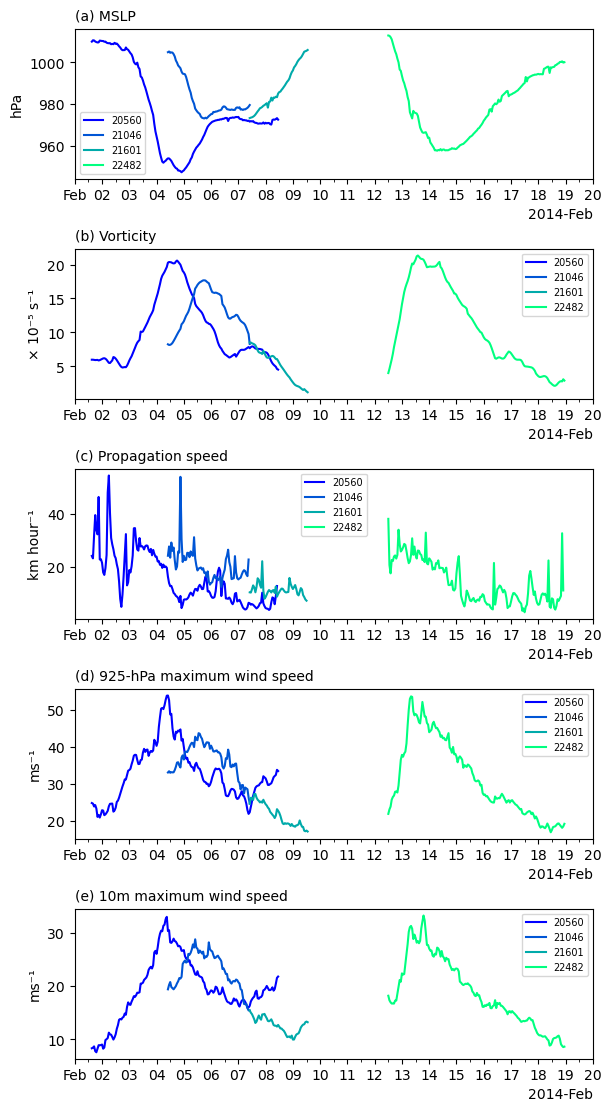

In [50]:
#import datetime
#start_datetime = datetime.datetime(2014, 2, 1)
#end_datetime = datetime.datetime(2014, 2, 19)
#waktuini = [start_datetime, end_datetime]
fig, axs = plt.subplots(figsize=(6., 11.), nrows=5, ncols=1, constrained_layout=True)
converter = mdates.ConciseDateConverter(formats=formats, zero_formats=zero_formats, show_offset=0)
locator = mdates.AutoDateLocator(minticks=6, maxticks=24)
formatter = mdates.ConciseDateFormatter(locator)

for ax in axs:
    ax.set_xlim(waktuini)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.xaxis.set_minor_locator(mdates.HourLocator(interval=12))
    
variables = ['var_mslp', 'var_vor', 'speed', 'var_wind', 'var_prec']
titles = ['(a) MSLP', '(b) Vorticity', '(c) Propagation speed', '(d) 925-hPa maximum wind speed', '(e) 10m maximum wind speed']
ylabels = ['hPa', '× 10⁻⁵ s⁻¹', 'km hour⁻¹', 'ms⁻¹', 'ms⁻¹']
cmap = cm.get_cmap('winter', len(storm_id_sel))
for idx, (var, title, ylabel) in enumerate(zip(variables, titles, ylabels)):
    for storm_idx, (name, group) in enumerate(trx_sel.groupby('ID')):
        if var in group.columns:
            color = cmap(storm_idx)
            axs[idx].plot(group['date'], group[var], label=f'{name}', color=color)
        else:
            print(f"Variable {var} not found in group columns")
            
    axs[idx].set_ylabel(ylabel)
    axs[idx].set_title(title, loc='left', fontsize=10)
    axs[idx].legend(frameon=True, fancybox=True, fontsize=7, loc='best')

plt.show()

## Synops Map

In [29]:
dec_mslp = xr.open_dataset('feb_mslp.nc')
msl_ = dec_mslp['msl'] / 100
msl_clim = msl_.mean(dim='time')

msl_anom = msl - msl_clim
msl_anom.max()

lonsi = msl_anom['longitude']
latsi = msl_anom['latitude']

msl_anom_all = msl_anom.mean(dim='time')
uwnd_all = uwnd.mean(dim='time')
vwnd_all = vwnd.mean(dim='time')

/tmp/ipykernel_1866/3514304127.py:31: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for collection in cs.collections:
/tmp/ipykernel_1866/3514304127.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('winter', len(storm_id_sel))


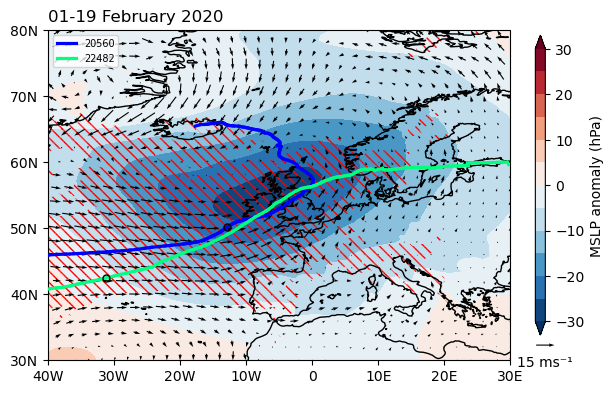

In [30]:
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
datacrs = ccrs.PlateCarree()
boundary = [-40, 30, 80, 30]
lons_tick = [-40, -30, -20, -10, 0, 10, 20, 30]
lats_tick = [80, 70, 60, 50, 40, 30]

fig, ax = plt.subplots(1, 1, sharey=True, sharex=True, figsize=(5., 5.), subplot_kw={'projection': datacrs})
ax.set_extent(boundary, crs=datacrs) 
ax.set_xticks(lons_tick, crs=datacrs)  
ax.set_yticks(lats_tick, crs=datacrs)  
ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=True))
ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol=''))
ax.coastlines(linewidth=1)  

colorvim_levels = np.arange(-30, 35, 5)
contf = ax.contourf(lonsi, latsi, msl_anom_all, levels=colorvim_levels, cmap=plt.cm.RdBu_r, extend='both', transform=datacrs, zorder=0)

skip=(slice(None,None,8),slice(None,None,8))
wind_vec_plot = ax.quiver(lons[skip], lats[skip], uwnd_all[skip], vwnd_all[skip], 
                              pivot='tip', transform=datacrs, zorder=5)

ax.quiverkey(wind_vec_plot, 1.12, 0.2, 15, '15 ms⁻¹', labelpos='S', zorder=24,
                   coordinates='figure')

col_map = np.arange(20, 100, 10)

levels = np.linspace(50, np.max(prec_sum), num=50)
prec_sum_masked = np.ma.masked_less_equal(prec_sum, 50)
cs = ax.contourf(lons, lats, prec_sum_masked, levels=levels, hatches=['\\\\\\'], vmin=25, extend='max', colors='None',
                 transform=datacrs)
for collection in cs.collections:
    collection.set_edgecolor('red')
    collection.set_linewidth(0)
    
cmap = cm.get_cmap('winter', len(storm_id_sel))
lines = []
labels = []

for idx, (name, group) in enumerate(trx_sel.groupby('ID')):
    color = cmap(idx)
    points = group[['lon_vor', 'lat_vor']].values
    for i in range(len(points) - 1):
        line = np.array([points[i], points[i + 1]])
        line_obj, = ax.plot(line[:, 0], line[:, 1], color=color, linewidth=2.3, transform=datacrs, zorder=20)
        
    lines.append(line_obj)
    labels.append(f'{name}')

    min_mslp_idx = group['var_vor'].idxmax()
    min_mslp_point = group.loc[min_mslp_idx, ['lon_vor', 'lat_vor']]
    
    # Plot the point with the minimum var_mslp value
    ax.plot(min_mslp_point['lon_vor'], min_mslp_point['lat_vor'], 'o', color=color, markersize=5, markeredgecolor='white',
            markerfacecolor='None', transform=datacrs, zorder=21)

ax.set_title('01-19 February 2014', weight='normal', loc='left')
ax.legend(lines, labels, loc='upper left', fontsize=7)

fig.subplots_adjust(bottom=0.1, right=1.05, top=0.9, wspace=0.12, hspace=0.25)
cax = fig.add_axes([1.1, 0.22, 0.02, 0.6])
#dax = fig.add_axes([1.3, 0.22, 0.02, 0.6])
cb = plt.colorbar(contf, cax=cax, orientation='vertical', aspect=20)
cb.set_label('MSLP anomaly (hPa)')

#pr = plt.colorbar(contf_prec, cax=dax, orientation='vertical', aspect=20)
#pr.set_label('Total precipitation (mm)')

#plt.savefig('fig_anom_msl.png', dpi=300, bbox_inches='tight')
plt.show()

## Animation

In [34]:
sel_trx = trx_sel[(trx_sel['date'] >= '2014-02-06 00:00:00') & (trx_sel['date'] <= '2014-02-17 23:00:00')]
time_sel_trx = sel_trx['date'].nunique
time_sel_trx

<bound method IndexOpsMixin.nunique of 1450   2014-02-06 00:00:00
1451   2014-02-06 01:00:00
1452   2014-02-06 02:00:00
1453   2014-02-06 03:00:00
1454   2014-02-06 04:00:00
               ...        
1637   2014-02-17 19:00:00
1638   2014-02-17 20:00:00
1639   2014-02-17 21:00:00
1640   2014-02-17 22:00:00
1641   2014-02-17 23:00:00
Name: date, Length: 192, dtype: datetime64[ns]>

In [46]:
sel_trx = trx[(trx['date'] >= '2014-02-06 00:00:00') & (trx['date'] <= '2014-02-17 23:00:00')]
time_sel_trx = sel_trx['date'].nunique
time_sel_trx

<bound method IndexOpsMixin.nunique of 3202    2014-02-06 00:00:00
3203    2014-02-06 01:00:00
3204    2014-02-06 02:00:00
3205    2014-02-06 03:00:00
3206    2014-02-06 04:00:00
               ...         
3561    2014-02-17 19:00:00
3562    2014-02-17 20:00:00
3563    2014-02-17 21:00:00
3564    2014-02-17 22:00:00
3565    2014-02-17 23:00:00
Name: date, Length: 279, dtype: object>

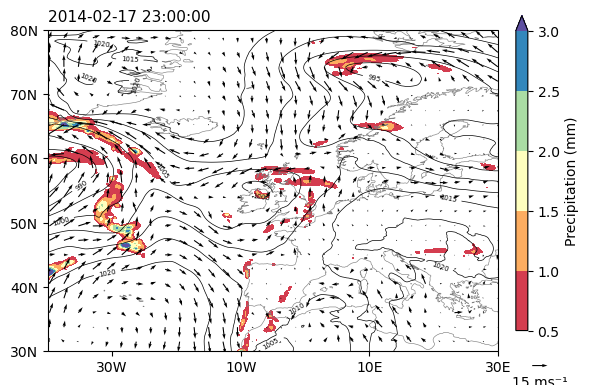

In [47]:
from matplotlib.animation import FuncAnimation

mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
datacrs = ccrs.PlateCarree()
boundary = [-40, 30, 80, 30]
lons_tick = [-30, -10, 10, 30] 
lats_tick = [80, 70, 60, 50, 40, 30]
colorvim_levels = np.arange(0.5, 3.5, 0.5)
cbar = np.arange(960, 1025, 5) 
timesel = pd.date_range(start='2014-02-06 00:00:00', end='2014-02-17 23:00:00', freq='h')

fig, ax = plt.subplots(1,1,sharey=True, sharex=True, figsize=(6., 7.), subplot_kw={'projection': datacrs})
ax.set_extent(boundary, crs=datacrs) 
ax.set_xticks(lons_tick, crs=datacrs)  
ax.set_yticks(lats_tick, crs=datacrs)  
ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=True))
ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol=''))
ax.coastlines(linewidth=0.85, color='grey')  
contf = ax.contourf(lons, lats, prec.sel(time=timesel[0]), levels=colorvim_levels, vmin=0.5, cmap=plt.cm.Spectral, 
                    extend='max', transform=datacrs, zorder=0)

fig.subplots_adjust(left=0.1, bottom=0.1, right=0.85, top=0.9, wspace=0.12, hspace=0.25)
cax = fig.add_axes([0.88, 0.3, 0.02, 0.45])
cb = plt.colorbar(contf, cax=cax, orientation='vertical', aspect=50)
cb.set_label('Precipitation (mm)')

def update(time):
    ax.clear()
    ax.set_extent(boundary, crs=datacrs) 
    ax.set_xticks(lons_tick, crs=datacrs)  
    ax.set_yticks(lats_tick, crs=datacrs)  
    time_track = pd.to_datetime(time)
    track_lon = sel_trx.loc[sel_trx['date'] == time_track, 'lon_vor']
    track_lat = sel_trx.loc[sel_trx['date'] == time_track, 'lat_vor']
    ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol=''))
    ax.coastlines(linewidth=0.45, color='grey')

    contf = ax.contourf(lons, lats, prec.sel(time=time), levels=colorvim_levels, vmin=0.5, cmap=plt.cm.Spectral, extend='max', transform=datacrs, zorder=0)
    skip=(slice(None,None,9),slice(None,None,9))
    wind_vec_plot = ax.quiver(lons[skip], lats[skip], uwnd.sel(time=time)[skip], vwnd.sel(time=time)[skip], 
                                pivot='tail', transform=datacrs, zorder=5)
    contour_lines = ax.contour(lons, lats, msl.sel(time=time), cbar, colors='black', linewidths=0.5, zorder=10, transform=datacrs)
    ax.clabel(contour_lines, inline=True, fontsize=5, fmt='%.0f')
    ax.quiverkey(wind_vec_plot, 0.92, 0.25, 15, '15 ms⁻¹', labelpos='S', zorder=24, coordinates='figure')    
    ax.plot(track_lon, track_lat, 'o', color='blue', markersize=6, markeredgecolor='white',
            markerfacecolor='blue', transform=datacrs, zorder=27)
    ax.set_title(f'{time}', weight='normal', loc='left', fontsize=11)

ani = FuncAnimation(fig, update, frames=timesel, repeat=False)
ani.save('feb_2014_tracks-smallstorm.mp4', writer='ffmpeg', fps=4, dpi=300)

plt.show()
